# Exploratory Analysis — District Development & Governance Analytics

This notebook explores the two source datasets (baseline development scores and improvement/delta scores) from NITI Aayog's Aspirational Districts Programme, walks through the preprocessing and merge step, and reproduces the Level–Momentum segmentation and K-Means clustering used in the Streamlit dashboard (`app.py`).

See [`docs/methodology.md`](../docs/methodology.md) for the full write-up of the analytical approach.


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from data_loader import load_data
from preprocessing import merge_datasets
from segmentation import create_quadrants, create_clusters
from recommendations import add_recommendations
from insights import (
    get_overall_metrics,
    get_critical_by_state,
    get_top_momentum_districts,
    get_lowest_level_districts,
    get_quadrant_summary,
)

pd.set_option("display.max_columns", None)


## 1. Load the raw datasets

In [2]:
baseline, delta = load_data()

print("Baseline shape:", baseline.shape)
baseline.head()

Baseline shape: (101, 4)


        district           state  baseline_score  baseline_rank
0   Vizianagaram  Andhra Pradesh           48.13              1
1    Rajnandgaon    Chhattisgarh           47.96              2
2      Osmanabad     Maharashtra           47.53              3
3       Cuddapah  Andhra Pradesh           47.43              4
4  Ramanathapuram      Tamil Nadu           46.78              5

In [3]:
print("Delta shape:", delta.shape)
delta.head()

Delta shape: (108, 4)


        district           state  delta  delta_rank
0          Dahod         Gujarat   19.8           1
1    West Sikkim          Sikkim   18.9           2
2 Ramanathapuram      Tamil Nadu   17.7           3
3   Vizianagaram  Andhra Pradesh   17.5           4
4         Y.S.R.  Andhra Pradesh   14.9           5

Note the row counts already differ: **101** baseline districts vs **108** delta districts.
The delta file includes a handful of districts (mostly in Odisha) that never appear in the baseline
file, and some districts are spelled differently across the two files (e.g. `Y.S.R.` vs `Cuddapah`,
`Dahod` vs `Dohad`). Both issues are handled in `preprocessing.py` before merging.

## 2. Clean district names and merge the two datasets

In [4]:
df = merge_datasets()

print("Merged shape:", df.shape)
df.head()

Merged shape: (101, 7)


        district           state  baseline_score  baseline_rank district_key  delta  delta_rank
0   Vizianagaram  Andhra Pradesh           48.13              1  vizianagaram   17.5           4
1    Rajnandgaon    Chhattisgarh           47.96              2   rajnandgaon    6.8          37
2      Osmanabad     Maharashtra           47.53              3     osmanabad    5.7          52
3       Cuddapah  Andhra Pradesh           47.43              4    ysr kadapa   14.9           5
4  Ramanathapuram      Tamil Nadu           46.78              5 ramanathapuram   17.7           3

The inner join on the standardised `district_key` keeps every one of the 101 baseline districts,
since the alias map resolves all the naming mismatches. The 7 districts present only in the delta
file (not in baseline) are dropped by the join — this is expected, not a bug.

## 3. Level–Momentum quadrant segmentation

In [5]:
df, level_median, momentum_median = create_quadrants(df)

print("Median baseline score (Level):", round(level_median, 2))
print("Median delta (Momentum):", round(momentum_median, 2))

Median baseline score (Level): 35.42
Median delta (Momentum): 5.7


In [6]:
get_quadrant_summary(df)

                    quadrant  districts
0  High Level / High Momentum         32
1           Critical Priority         31
2   High Level / Low Momentum         19
3   Low Level / High Momentum         19

## 4. Visualising the Level–Momentum matrix

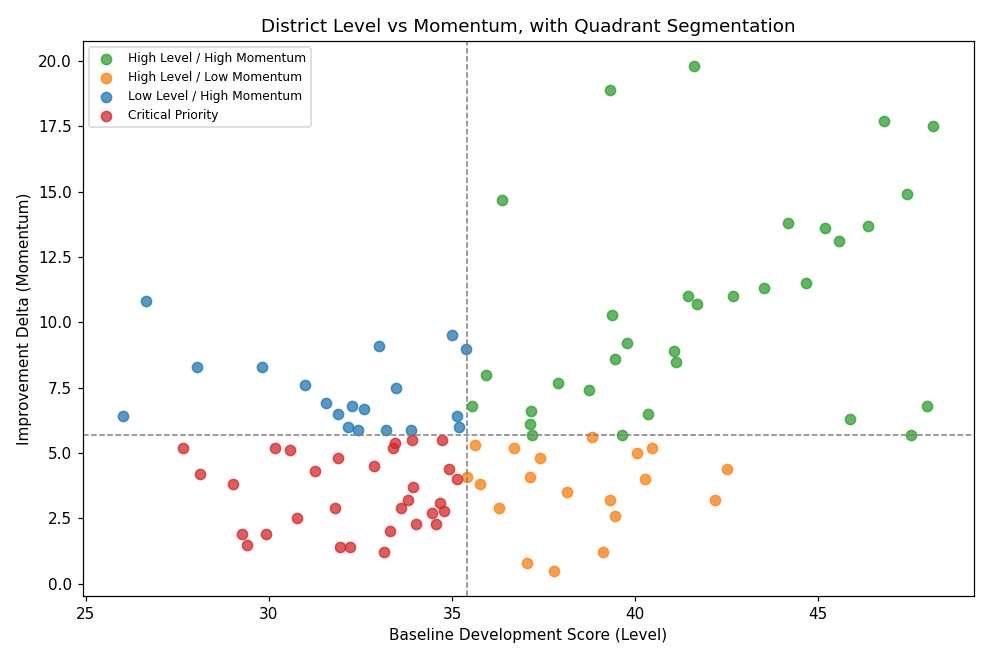

In [7]:
colors = {
    "High Level / High Momentum": "#2ca02c",
    "High Level / Low Momentum": "#ff7f0e",
    "Low Level / High Momentum": "#1f77b4",
    "Critical Priority": "#d62728",
}

fig, ax = plt.subplots(figsize=(9, 6))
for quad, color in colors.items():
    sub = df[df["quadrant"] == quad]
    ax.scatter(sub["baseline_score"], sub["delta"], label=quad, color=color, alpha=0.75, s=45)

ax.axvline(level_median, color="gray", linestyle="--", linewidth=1)
ax.axhline(momentum_median, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Baseline Development Score (Level)")
ax.set_ylabel("Improvement Delta (Momentum)")
ax.set_title("District Level vs Momentum, with Quadrant Segmentation")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 5. K-Means clustering (secondary, unsupervised segmentation)

In [8]:
df = create_clusters(df)

df["cluster_profile"].value_counts()

cluster_profile
Lagging but Accelerating    32
Lagging & Stalled           28
Established but Slowing     26
Leading Accelerators        15
Name: count, dtype: int64

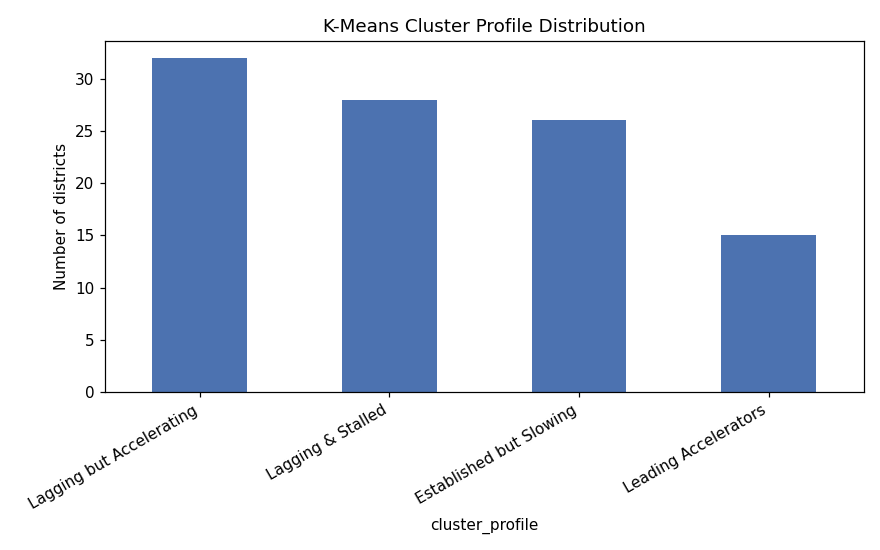

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
df["cluster_profile"].value_counts().plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_ylabel("Number of districts")
ax.set_title("K-Means Cluster Profile Distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Note that the K-Means cluster sizes don't exactly match the quadrant sizes (e.g. 32/28/26/15
here vs 32/31/19/19 for the quadrants). This is expected: K-Means groups districts by proximity to
data-driven centroids, while the quadrant model uses fixed median cutoffs. Districts near a
boundary can land in different groups under the two methods — a useful signal for districts worth
a closer look.

## 6. Policy recommendations

In [10]:
df = add_recommendations(df)

df[["district", "state", "quadrant", "policy_recommendation"]].head(5)

        district           state                     quadrant                                                                             policy_recommendation
0   Vizianagaram  Andhra Pradesh  High Level / High Momentum        Document best practices and use the district as a peer-learning benchmark.
1    Rajnandgaon    Chhattisgarh  High Level / High Momentum        Document best practices and use the district as a peer-learning benchmark.
2      Osmanabad     Maharashtra  High Level / High Momentum        Document best practices and use the district as a peer-learning benchmark.
3       Cuddapah  Andhra Pradesh  High Level / High Momentum        Document best practices and use the district as a peer-learning benchmark.
4  Ramanathapuram      Tamil Nadu  High Level / High Momentum        Document best practices and use the district as a peer-learning benchmark.

## 7. National and state-level insights

In [11]:
metrics = get_overall_metrics(df, level_median, momentum_median)
metrics

{'total_districts': 101,
 'critical_priority': 31,
 'high_momentum': 51,
 'states': 25,
 'median_baseline': 35.42,
 'median_momentum': 5.7}

In [12]:
get_critical_by_state(df)

state
Jharkhand         11
Bihar              8
Assam              4
Uttar Pradesh      4
Chhattisgarh       2
Madhya Pradesh     2
dtype: int64

**Jharkhand (11)** and **Bihar (8)** together account for over 60% of all Critical Priority
districts — a strong geographic concentration worth flagging in any policy discussion.

In [13]:
get_top_momentum_districts(df, n=10)[["district", "state", "baseline_score", "delta", "quadrant"]]

          district           state  baseline_score  delta                    quadrant
16           Dohad         Gujarat           41.61   19.8 High Level / High Momentum
29     West Sikkim          Sikkim           39.31   18.9 High Level / High Momentum
4   Ramanathapuram      Tamil Nadu           46.78   17.7 High Level / High Momentum
0     Vizianagaram  Andhra Pradesh           48.13   17.5 High Level / High Momentum
3         Cuddapah  Andhra Pradesh           47.43   14.9 High Level / High Momentum
44         Bijapur    Chhattisgarh           36.36   14.7 High Level / High Momentum
10          Washim     Maharashtra           44.18   13.8 High Level / High Momentum
5    Udham Singh Nagar    Uttarakhand        46.36   13.7 High Level / High Momentum
8            Korba    Chhattisgarh           45.19   13.6 High Level / High Momentum
7     Virudhunagar      Tamil Nadu           45.57   13.1 High Level / High Momentum

Every one of the top-10 momentum districts already sits in the **High Level / High Momentum**
quadrant — meaning the fastest-improving districts in this dataset were not starting from the very
back of the pack. The districts that are both furthest behind *and* barely moving (**Critical
Priority**) are a distinct group, explored next.

In [14]:
get_lowest_level_districts(df, n=10)[["district", "state", "baseline_score", "delta", "quadrant"]]

       district             state  baseline_score  delta                   quadrant
100       Mewat           Haryana           26.02    6.4 Low Level / High Momentum
99     Asifabad         Telangana           26.64   10.8 Low Level / High Momentum
98    Singrauli    Madhya Pradesh           27.67    5.2          Critical Priority
97      Kiphire          Nagaland           28.04    8.3 Low Level / High Momentum
96   Shrawasti     Uttar Pradesh           28.13    4.2          Critical Priority
95    Bahraich     Uttar Pradesh           29.01    3.8          Critical Priority
94 Siddharthnagar    Uttar Pradesh           29.26    1.5          Critical Priority
93   Balrampur     Uttar Pradesh           29.41    1.5          Critical Priority
92      Namsai Arunachal Pradesh           29.82    8.3 Low Level / High Momentum
91       Sukma      Chhattisgarh           29.93    1.9          Critical Priority

Interestingly, several of the lowest-baseline districts (Mewat, Asifabad, Kiphire, Namsai)
still show **above-median momentum** — they are improving quickly despite starting from a low base,
placing them in **Low Level / High Momentum** rather than **Critical Priority**. The genuinely
concerning cases are districts like Shrawasti, Bahraich, Siddharthnagar, and Balrampur (all Uttar
Pradesh), which combine a low baseline score with weak improvement.

## 8. Summary

- 101 districts have both a baseline and a delta score and form the analysis cohort.
- The Level–Momentum framework splits them into four roughly-comparable groups, with
  **Critical Priority (31)** and **High Level / High Momentum (32)** the two largest.
- **Jharkhand** and **Bihar** account for the majority of Critical Priority districts.
- The K-Means clustering broadly agrees with the quadrant model but disagrees for districts near
  the median boundaries — useful for flagging edge cases for manual review.
- Full findings and caveats are documented in [`docs/methodology.md`](../docs/methodology.md) and
  the project [`README.md`](../README.md).
